(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

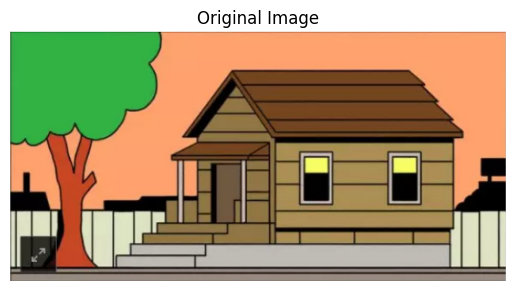

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as LeHoangHiep

img = cv2.imread('hinh1.png')

LeHoangHiep.imshow(img[:,:,::-1])
LeHoangHiep.title("Original Image")
LeHoangHiep.axis("off")

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

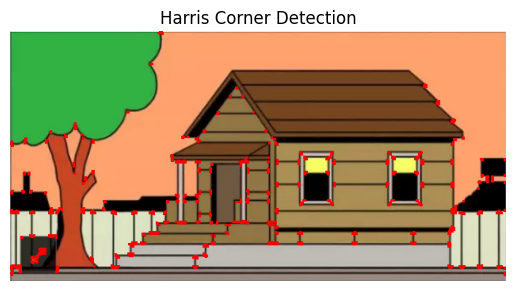

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

dst = cv2.cornerHarris(gray,2,3,0.04)

dst = cv2.dilate(dst,None)

img_harris = img.copy()
img_harris[dst > 0.01*dst.max()] = [0,0,255]

LeHoangHiep.imshow(img_harris[:,:,::-1])
LeHoangHiep.title("Harris Corner Detection")
LeHoangHiep.axis("off")

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

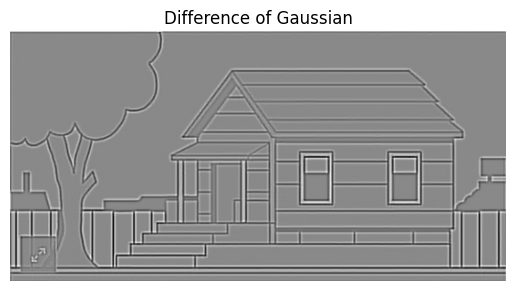

In [4]:
blur1 = cv2.GaussianBlur(gray,(5,5),1)
blur2 = cv2.GaussianBlur(gray,(5,5),2)

dog = blur1 - blur2

LeHoangHiep.imshow(dog,cmap='gray')
LeHoangHiep.title("Difference of Gaussian")
LeHoangHiep.axis("off")

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

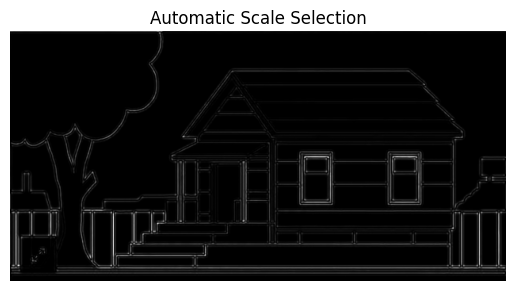

In [10]:
sigmas = [1,2,3,4]

responses = []

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = gray.astype(np.float64)

for s in sigmas:
    blur = cv2.GaussianBlur(gray,(0,0),s)
    log = cv2.Laplacian(blur, cv2.CV_64F)
    responses.append(log**2)

max_response = np.maximum.reduce(responses)

LeHoangHiep.imshow(max_response, cmap='gray')
LeHoangHiep.title("Automatic Scale Selection")
LeHoangHiep.axis("off")

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

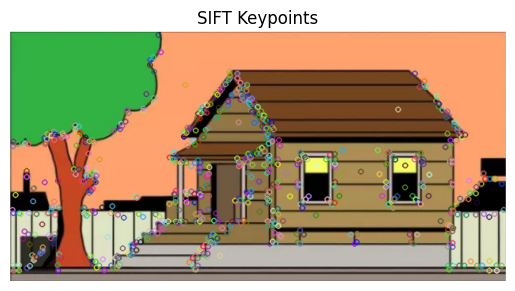

In [12]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = gray.astype('uint8')

sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray,None)

img_sift = cv2.drawKeypoints(img,kp,None)

LeHoangHiep.imshow(img_sift[:,:,::-1])
LeHoangHiep.title("SIFT Keypoints")
LeHoangHiep.axis("off")

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

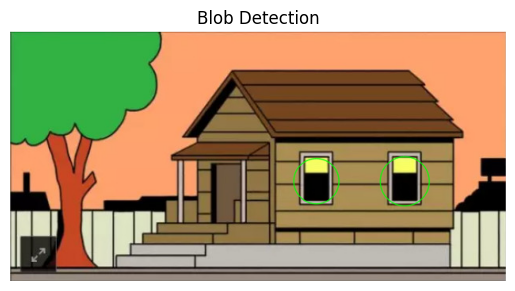

In [13]:
detector = cv2.SimpleBlobDetector_create()

keypoints = detector.detect(gray)

img_blob = cv2.drawKeypoints(img,keypoints,np.array([]),(0,255,0),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

LeHoangHiep.imshow(img_blob[:,:,::-1])
LeHoangHiep.title("Blob Detection")
LeHoangHiep.axis("off")

In [14]:
sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray,None)

print("Number of descriptors:", des.shape)

Number of descriptors: (772, 128)


(np.float64(-0.5), np.float64(1251.5), np.float64(314.5), np.float64(-0.5))

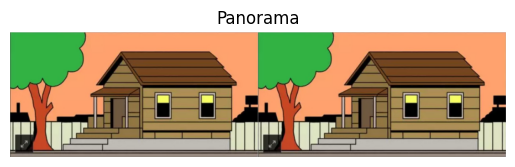

In [24]:
img2 = cv2.imread('hinh2.png')

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img, img2])

if pano is None:
    pano = np.hstack((img, img2))

LeHoangHiep.imshow(pano[:,:,::-1])
LeHoangHiep.title("Panorama")
LeHoangHiep.axis("off")

(np.float64(-0.5), np.float64(1251.5), np.float64(314.5), np.float64(-0.5))

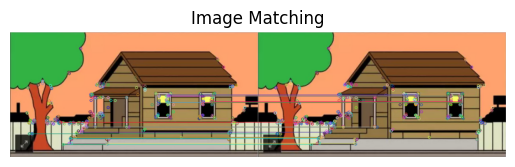

In [25]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img,None)
kp2, des2 = orb.detectAndCompute(img2,None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.match(des1,des2)

matches = sorted(matches,key=lambda x:x.distance)

img_match = cv2.drawMatches(img,kp1,img2,kp2,matches[:20],None)

LeHoangHiep.imshow(img_match[:,:,::-1])
LeHoangHiep.title("Image Matching")
LeHoangHiep.axis("off")

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

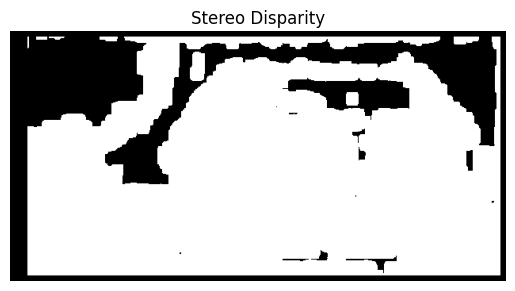

In [26]:
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

disparity = stereo.compute(gray,gray2)

LeHoangHiep.imshow(disparity,cmap='gray')
LeHoangHiep.title("Stereo Disparity")
LeHoangHiep.axis("off")

In [27]:
hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])

print("Histogram shape:",hist.shape)

Histogram shape: (8, 8, 8)


In [28]:
sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray,None)

histogram = np.histogram(des,bins=20)

print(histogram)

(array([60866,  9460,  5646,  4261,  2842,  2299,  1709,  1583,  1222,
        1215,  1286,  2015,  2030,  1168,   698,   282,   173,    29,
          16,    16]), array([  0.      ,  10.55    ,  21.1     ,  31.650002,  42.2     ,
        52.75    ,  63.300003,  73.85    ,  84.4     ,  94.950005,
       105.5     , 116.05    , 126.600006, 137.15001 , 147.7     ,
       158.25    , 168.8     , 179.35    , 189.90001 , 200.45    ,
       211.      ], dtype=float32))
